# Questão 4

Análise da concentração de energia da imagem `sosias.jpg` no domínio da DCT2.

Este notebook procura `sosias.jpg` em `pratica_4/` e em `data/`.


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import dctn
from PIL import Image

plt.style.use('seaborn-v0_8-whitegrid')

CWD = Path.cwd().resolve()

def find_repo_root(start_path):
    for candidate in [start_path, *start_path.parents]:
        if (candidate / 'data').exists() and (candidate / 'pratica_4').exists():
            return candidate
    raise FileNotFoundError(
        'Repositorio nao encontrado. Execute o notebook dentro da pasta do projeto.'
    )

REPO_ROOT = find_repo_root(CWD)
PRACTICE_DIR = REPO_ROOT / 'pratica_4'
DATA_DIR = REPO_ROOT / 'data'

def find_image():
    candidates = [
        PRACTICE_DIR / 'sosias.jpg',
        DATA_DIR / 'sosias.jpg',
        DATA_DIR / 'sosias.jpeg',
        DATA_DIR / 'sosias.png',
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        'Imagem sosias.jpg nao encontrada. Coloque o arquivo em pratica_4/ ou data/.'
    )


In [2]:
def display_rows(rows, float_digits=6):
    if not rows:
        print('Sem dados para exibir.')
        return

    headers = list(rows[0].keys())
    formatted_rows = []
    for row in rows:
        formatted = []
        for header in headers:
            value = row[header]
            if isinstance(value, float):
                formatted.append(f'{value:.{float_digits}f}')
            else:
                formatted.append(str(value))
        formatted_rows.append(formatted)

    widths = []
    for idx, header in enumerate(headers):
        content_width = max(len(row[idx]) for row in formatted_rows)
        widths.append(max(len(header), content_width))

    header_line = ' | '.join(header.ljust(widths[idx]) for idx, header in enumerate(headers))
    separator = '-+-'.join('-' * width for width in widths)
    print(header_line)
    print(separator)
    for row in formatted_rows:
        print(' | '.join(value.ljust(widths[idx]) for idx, value in enumerate(row)))
def load_gray_image():
    image_path = find_image()
    image = Image.open(image_path).convert('L')
    return image_path, np.asarray(image, dtype=np.float64) / 255.0


In [3]:
image_path, image = load_gray_image()
coeffs = dctn(image, norm='ortho')
energy = coeffs ** 2
cumulative = np.cumsum(np.sort(energy.ravel())[::-1]) / np.sum(energy)

print(f'Imagem usada: {image_path}')
print(f'Dimensoes: {image.shape[1]} x {image.shape[0]}')
print(f'Coeficientes totais: {image.size}')


Imagem usada: C:\Users\pedro\OneDrive - cefet-rj.br\Faculdade\Processamento-de-Sinais-1\data\sosias.jpg
Dimensoes: 1200 x 670
Coeficientes totais: 804000


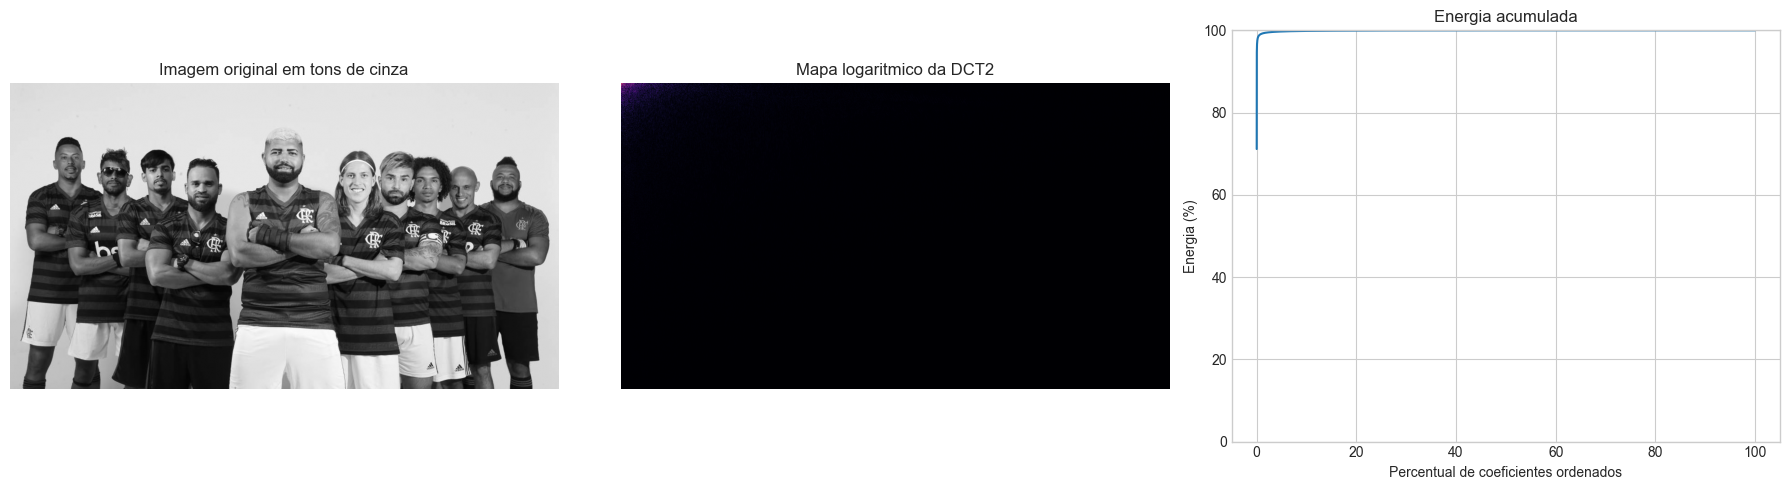

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Imagem original em tons de cinza')
axes[0].axis('off')

axes[1].imshow(np.log1p(np.abs(coeffs)), cmap='magma')
axes[1].set_title('Mapa logaritmico da DCT2')
axes[1].axis('off')

axes[2].plot(np.linspace(0, 100, len(cumulative)), cumulative * 100)
axes[2].set_title('Energia acumulada')
axes[2].set_xlabel('Percentual de coeficientes ordenados')
axes[2].set_ylabel('Energia (%)')
axes[2].set_ylim(0, 100)

plt.tight_layout()
plt.show()


## Comentários

- A DCT2 tende a concentrar boa parte da energia em frequências espaciais baixas.
- Isso aparece visualmente no canto superior esquerdo do mapa da DCT.
- Essa concentração explica por que a DCT é útil para compressão de imagens.
